Name: Bishwo Raj Dhami \
Id: 2413996

## Imports & Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

---
## Exercise 1 – Colour Image Processing (PIL + NumPy)

### Task 1 · Read and display the image

Image shape : (500, 500, 3)
dtype       : uint8
Min / Max   : 0 / 255


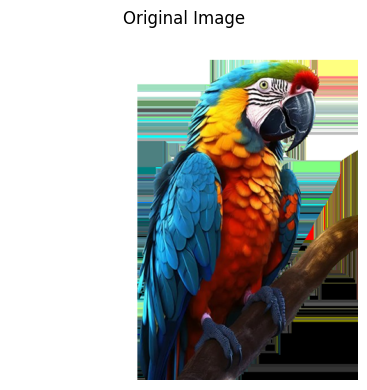

In [3]:

img_pil = Image.open('/content/drive/MyDrive/AI&ML/week1/image1.png').convert('RGB')
img = np.array(img_pil)

print(f'Image shape : {img.shape}')
print(f'dtype       : {img.dtype}')
print(f'Min / Max   : {img.min()} / {img.max()}')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img)
ax.set_title('Original Image')
ax.axis('off')
plt.tight_layout()
plt.show()

### Task 2 · Display the top-left 100×100 corner

Cropped shape: (100, 100, 3)


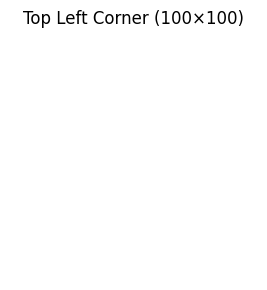

In [4]:
top_left = img[:100, :100, :]

print(f'Cropped shape: {top_left.shape}')

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(top_left)
ax.set_title('Top Left Corner (100×100)')
ax.axis('off')
plt.tight_layout()
plt.show()

### Task 3 · Show the three colour channels (R, G, B)

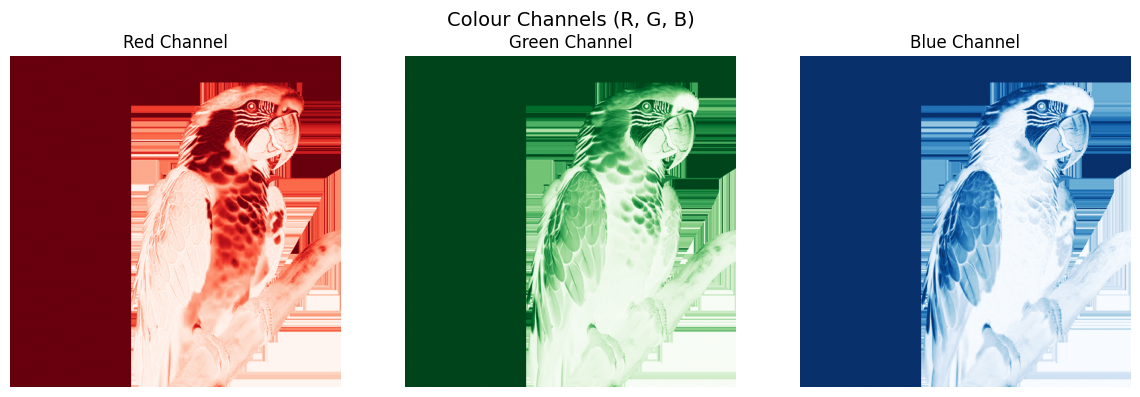

In [5]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(R, cmap='Reds')
axes[0].set_title('Red Channel')
axes[0].axis('off')

axes[1].imshow(G, cmap='Greens')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(B, cmap='Blues')
axes[2].set_title('Blue Channel')
axes[2].axis('off')

plt.suptitle('Colour Channels (R, G, B)', fontsize=14)
plt.tight_layout()
plt.show()

### Task 4 · Set top-left 100×100 pixels to 210 and display

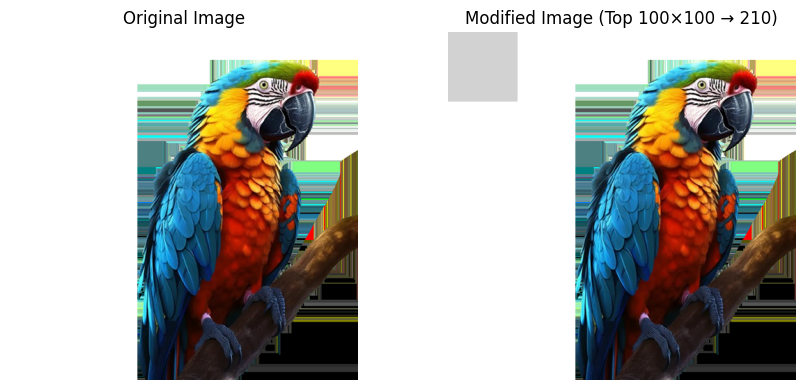

In [6]:
img_modified = img.copy()
img_modified[:100, :100, :] = 210

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_modified)
axes[1].set_title('Modified Image (Top 100×100 → 210)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Exercise 2 – Grayscale Image Processing

### Task 1 · Load and display the grayscale image

Grayscale image shape: (500, 500)


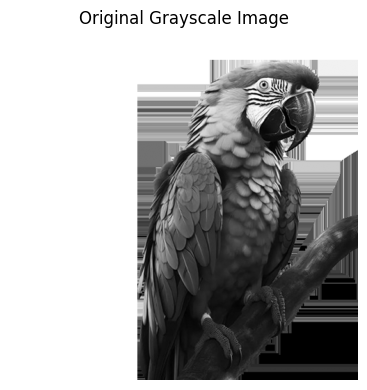

In [8]:
gray_pil = Image.open('/content/drive/MyDrive/AI&ML/week1/image1.png').convert('L')
gray = np.array(gray_pil)

print(f'Grayscale image shape: {gray.shape}')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(gray, cmap='gray')
ax.set_title('Original Grayscale Image')
ax.axis('off')
plt.tight_layout()
plt.show()

### Task 2 · Extract and display the middle 150×150 section

Middle section shape: (150, 150)


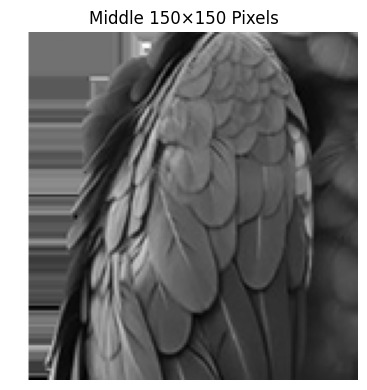

In [9]:
h, w = gray.shape
crop_size = 150

row_start = (h - crop_size) // 2
col_start = (w - crop_size) // 2

middle = gray[row_start : row_start + crop_size,
              col_start : col_start + crop_size]

print(f'Middle section shape: {middle.shape}')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(middle, cmap='gray')
ax.set_title('Middle 150×150 Pixels')
ax.axis('off')
plt.tight_layout()
plt.show()

### Task 3 · Threshold: pixels < 100 to 0, pixels >= 100 to 255

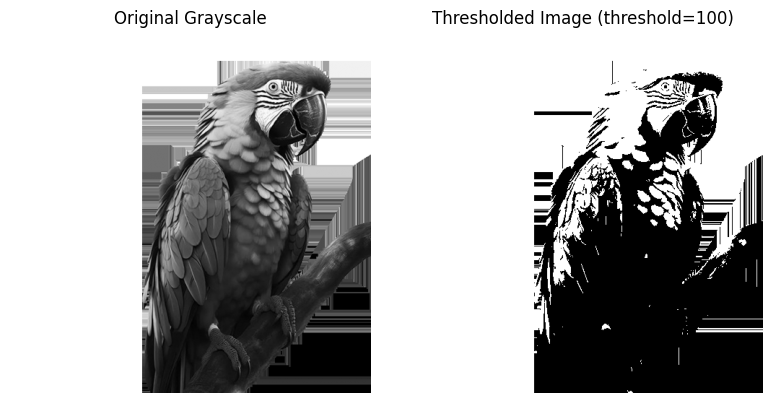

In [10]:
binary = gray.copy()
binary[binary < 100]  = 0
binary[binary >= 100] = 255

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Thresholded Image (threshold=100)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 4 · Rotate the image 90° clockwise

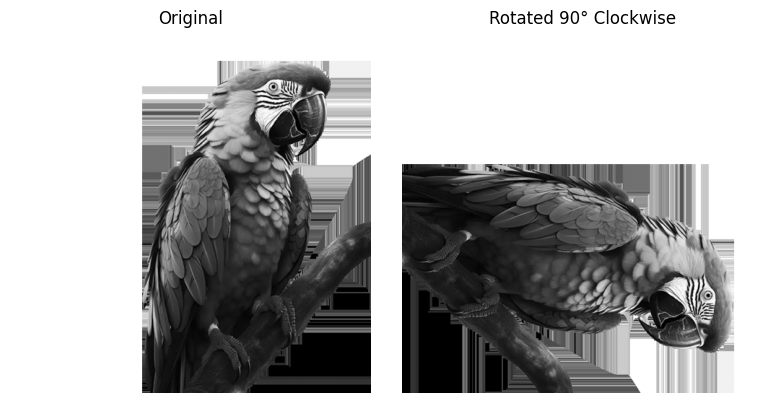

In [11]:

rotated_pil = gray_pil.rotate(-90, expand=True)
rotated = np.array(rotated_pil)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(rotated, cmap='gray')
axes[1].set_title('Rotated 90° Clockwise')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 5 · Convert grayscale image to RGB

RGB image shape: (500, 500, 3)


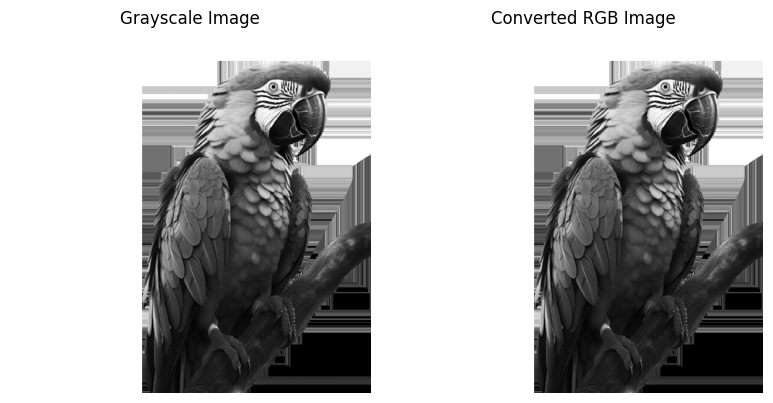

In [12]:
rgb_from_gray = np.stack([gray, gray, gray], axis=-1)

print(f'RGB image shape: {rgb_from_gray.shape}')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')

axes[1].imshow(rgb_from_gray)
axes[1].set_title('Converted RGB Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Exercise 3 – Image Compression using PCA (from scratch)


### Step 1 · Load, convert to grayscale, and standardise

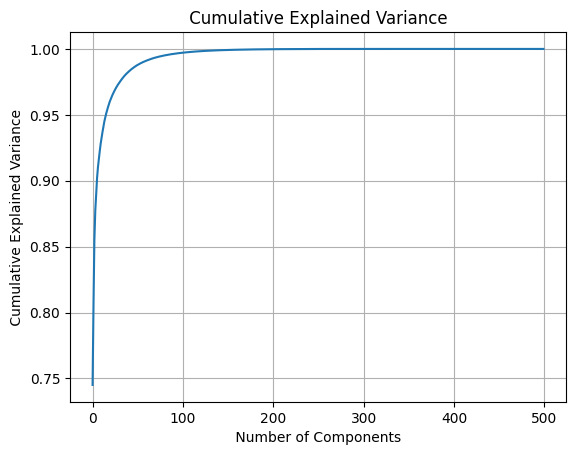

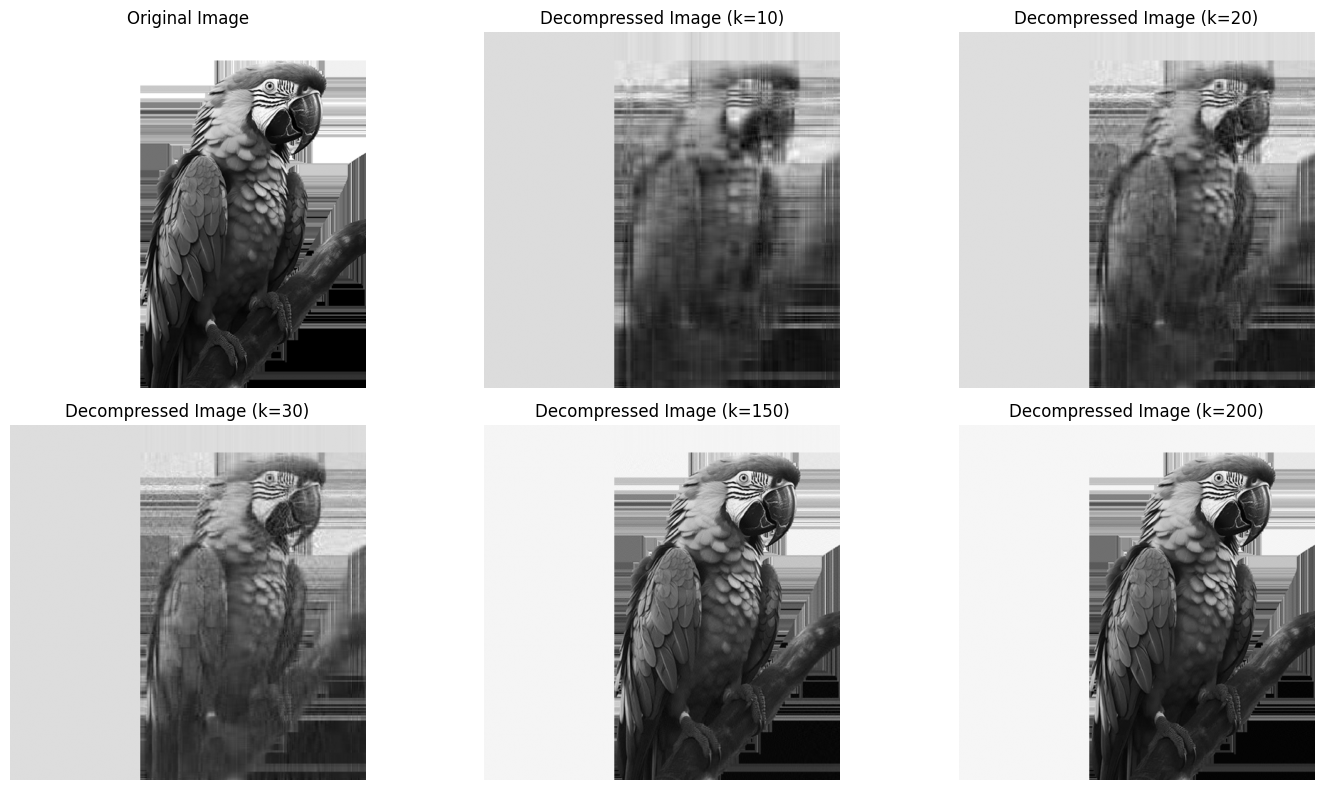

In [14]:
image = Image . open ('/content/drive/MyDrive/AI&ML/week1/image1.png') . convert ("L")
image_array = np . array ( image )
height , width = image_array . shape
data = image_array . reshape ( height , width )
# Standardize the Data
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean
# Compute Covariance Matrix
cov_matrix = np . cov ( centered_data , rowvar = False )
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )

plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()



k_values = [10,20,30,150,200] # Choose k principal components
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()  # makes indexing easy: axes[0], axes[1], etc.

# Plot original image first
axes[0].imshow(image_array, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")
for i, k in enumerate(k_values):
  components = eigenvectors [:,:k]

  # Project the data onto the principal components
  compressed_data = np.dot(centered_data,components)

  # Reconstruct the image from compressed data
  decompressed_data = np.dot( compressed_data ,components.T)+mean

  axes[i + 1].imshow(decompressed_data, cmap="gray")
  axes[i + 1].set_title (f"Decompressed Image (k={k})")
  axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

The cumulative explained variance plot shows that around 500 components capture nearly 99% of the image's variance, meaning most visual information is concentrated in a small number of principal components. At k=10, the reconstruction is very blurry with only broad shapes visible, but quality improves steadily as k increases. By k=150 and k=200, the decompressed images are nearly indistinguishable from the original, with fine textures well preserved. This demonstrates the core PCA trade-off lower k means higher compression but lower quality, while higher k recovers more detail with diminishing returns beyond a certain point.